# Part 4 — Vector Databases: Embeddings Demo
Generates sentence embeddings using `sentence-transformers`, computes a cosine similarity matrix, and finds the most similar sentences to a query.

In [1]:
!pip install sentence-transformers seaborn -q

In [2]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
sentences = [
    # Cricket
    "The batsman hit a stunning century in the final over.",
    "India won the match by five wickets against Australia.",
    "The spinner took two wickets in consecutive deliveries.",
    "Rain interrupted play during the third day of the Test match.",
    # Cooking
    "Saute the onions in olive oil until they turn golden brown.",
    "The recipe requires marinating the chicken for at least two hours.",
    "Add a pinch of salt and pepper to season the pasta sauce.",
    # Cybersecurity
    "The hacker exploited a SQL injection vulnerability in the web application.",
    "Always use two-factor authentication to protect your online accounts.",
    "A phishing email tricked the employee into revealing their password."
]
print(f"Total sentences: {len(sentences)}")

Total sentences: 10


In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)
print(f"Embedding shape: {embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: torch.Size([10, 384])


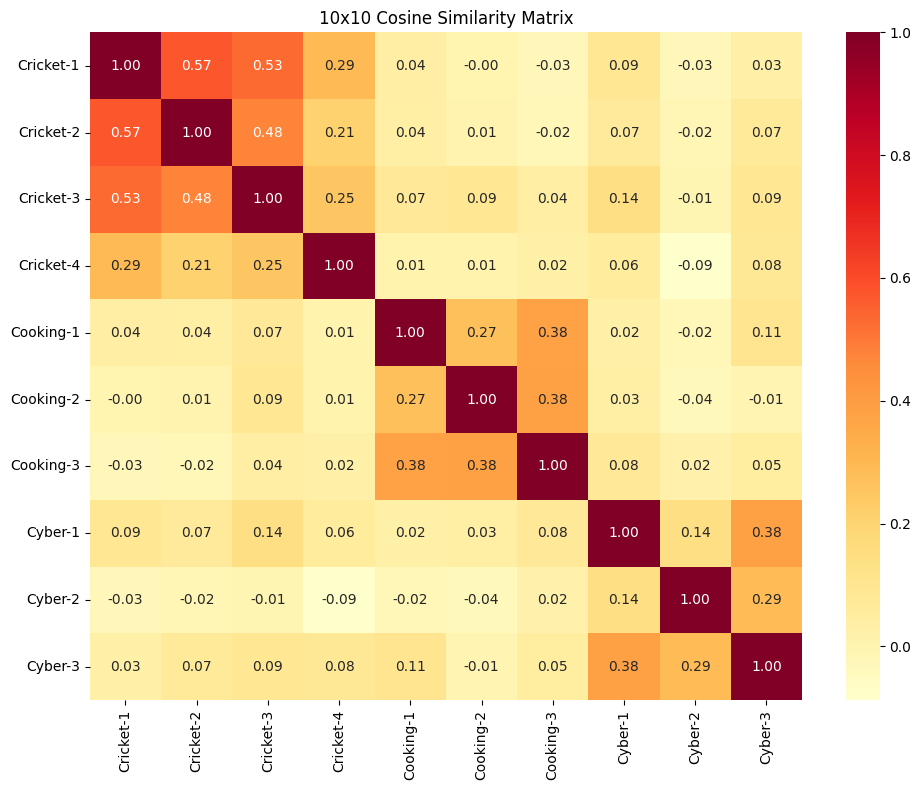

In [5]:
cosine_scores = util.cos_sim(embeddings, embeddings).numpy()

labels = [
    "Cricket-1", "Cricket-2", "Cricket-3", "Cricket-4",
    "Cooking-1", "Cooking-2", "Cooking-3",
    "Cyber-1", "Cyber-2", "Cyber-3"
]

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores, annot=True, fmt=".2f",
            xticklabels=labels, yticklabels=labels, cmap="YlOrRd")
plt.title("10x10 Cosine Similarity Matrix")
plt.tight_layout()
plt.show()

In [6]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)
query_scores = util.cos_sim(query_embedding, embeddings)[0].numpy()

top2_idx = np.argsort(query_scores)[::-1][:2]

print(f"Query: '{query}'\n")
print("Top 2 most similar sentences:")
for rank, idx in enumerate(top2_idx, 1):
    print(f"  {rank}. [{labels[idx]}] {sentences[idx]}")
    print(f"     Similarity score: {query_scores[idx]:.4f}")

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:
  1. [Cricket-3] The spinner took two wickets in consecutive deliveries.
     Similarity score: 0.7364
  2. [Cricket-2] India won the match by five wickets against Australia.
     Similarity score: 0.6351
